# TD3 baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from utils import TrajectoryReplayBuffer, collect_episode, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import TD3_Critic
from agents import TD3_Actor

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env


[TD3] step=  13002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  16002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  19002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  22002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  25002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  28002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  31002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  34002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  37002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  40002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  43002 | eval_return=0.000 | eval_len=500.0
[TD3] step=  46002 | eval_return=0.250 | eval_len=375.6
[TD3] step=  49002 | eval_return=0.000 | eval_len=500.0


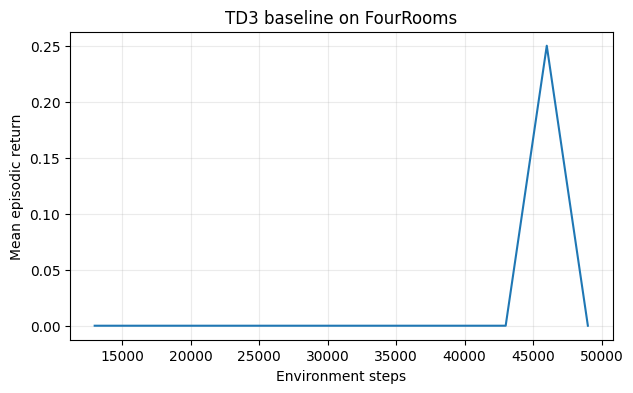

In [3]:

def td3_train(
    total_steps=100000,
    warmup_steps=10000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    policy_noise=0.2,
    noise_clip=0.5,
    policy_delay=2,
    expl_noise=0.15,
    lr=3e-4,
):
    env = make_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    actor = TD3_Actor(obs_dim, act_dim).to(DEVICE)
    actor_tgt = TD3_Actor(obs_dim, act_dim).to(DEVICE)
    actor_tgt.load_state_dict(actor.state_dict())

    q1, q2 = TD3_Critic(obs_dim, act_dim).to(DEVICE), TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q1_tgt, q2_tgt = TD3_Critic(obs_dim, act_dim).to(DEVICE), TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q1_tgt.load_state_dict(q1.state_dict())
    q2_tgt.load_state_dict(q2.state_dict())

    actor_opt = optim.Adam(actor.parameters(), lr=lr)
    critic_opt = optim.Adam(list(q1.parameters()) + list(q2.parameters()), lr=lr)

    replay = TrajectoryReplayBuffer(capacity=100_000, obs_dim=obs_dim, action_dim=act_dim, device=DEVICE)

    total_env_steps = 0
    train_it = 0
    eval_returns = []

    while total_env_steps < warmup_steps:
        ep, n = collect_episode(env, lambda _: env.action_space.sample())
        replay.add_episode(ep)
        total_env_steps += n

    while total_env_steps < total_steps:
        def behavior(obs):
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                a = actor(obs_t).squeeze(0).cpu().numpy()
            a = a + np.random.normal(0.0, expl_noise, size=act_dim)
            return np.clip(a, -1.0, 1.0).astype(np.float32)

        ep, n = collect_episode(env, behavior)
        replay.add_episode(ep)
        total_env_steps += n

        for _ in range(max(1, n // 2)):
            train_it += 1
            batch = replay.sample(batch_size)
            obs = batch.obs.float()
            act = batch.actions.float()
            rew = batch.rewards.float()
            next_obs = batch.next_obs.float()
            done = torch.clamp(batch.terminated + batch.truncated, 0, 1).float()

            with torch.no_grad():
                noise = torch.randn_like(act) * policy_noise
                noise = torch.clamp(noise, -noise_clip, noise_clip)
                next_a = torch.clamp(actor_tgt(next_obs) + noise, -1.0, 1.0)
                target_q = torch.min(q1_tgt(next_obs, next_a), q2_tgt(next_obs, next_a))
                y = rew + gamma * (1 - done) * target_q

            critic_loss = F.mse_loss(q1(obs, act), y) + F.mse_loss(q2(obs, act), y)
            critic_opt.zero_grad()
            critic_loss.backward()
            critic_opt.step()

            if train_it % policy_delay == 0:
                actor_loss = -q1(obs, actor(obs)).mean()
                actor_opt.zero_grad()
                actor_loss.backward()
                actor_opt.step()

                with torch.no_grad():
                    for p, pt in zip(actor.parameters(), actor_tgt.parameters()):
                        pt.data.mul_(1 - tau).add_(tau * p.data)
                    for p, pt in zip(q1.parameters(), q1_tgt.parameters()):
                        pt.data.mul_(1 - tau).add_(tau * p.data)
                    for p, pt in zip(q2.parameters(), q2_tgt.parameters()):
                        pt.data.mul_(1 - tau).add_(tau * p.data)

        if train_it % 300 == 0:
            eval_env = make_env()
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: actor(torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0))
                .squeeze(0).detach().cpu().numpy().astype(np.float32),
                episodes=8,
            )
            eval_returns.append((total_env_steps, mean_ret))
            print(f'[TD3] step={total_env_steps:7d} | eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}')
            eval_env.close()

    env.close()
    return actor, q1, eval_returns


td3_actor, td3_q1, td3_eval = td3_train()

if td3_eval:
    xs, ys = zip(*td3_eval)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('TD3 baseline on FourRooms')
    plt.grid(alpha=0.25)
    plt.show()


## Visualisations

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


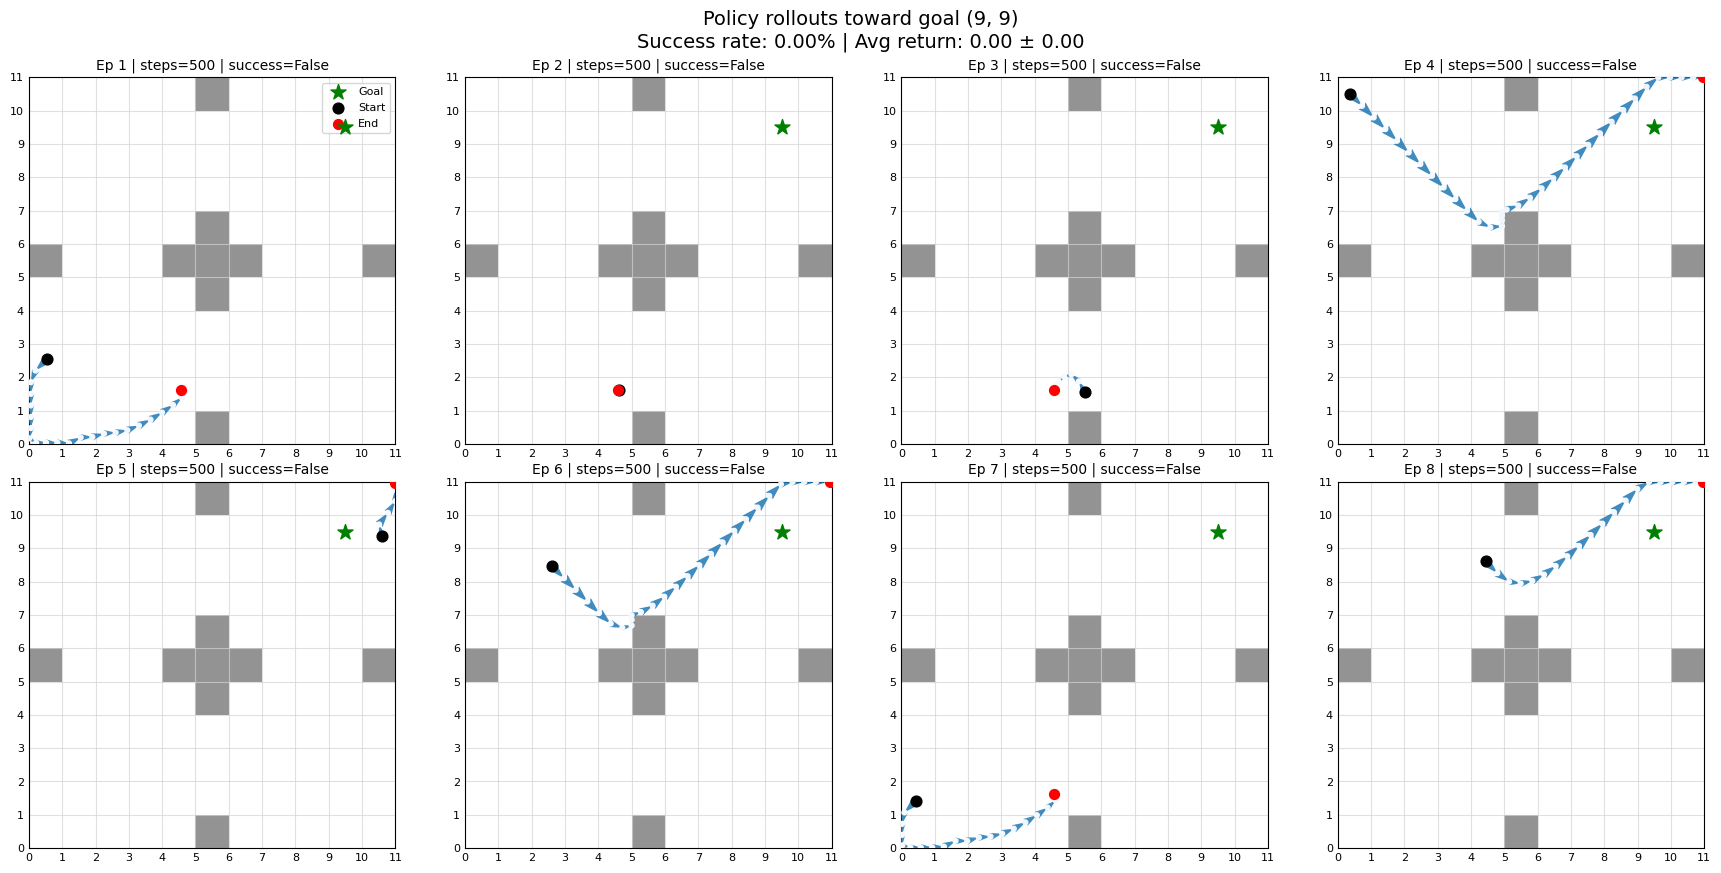

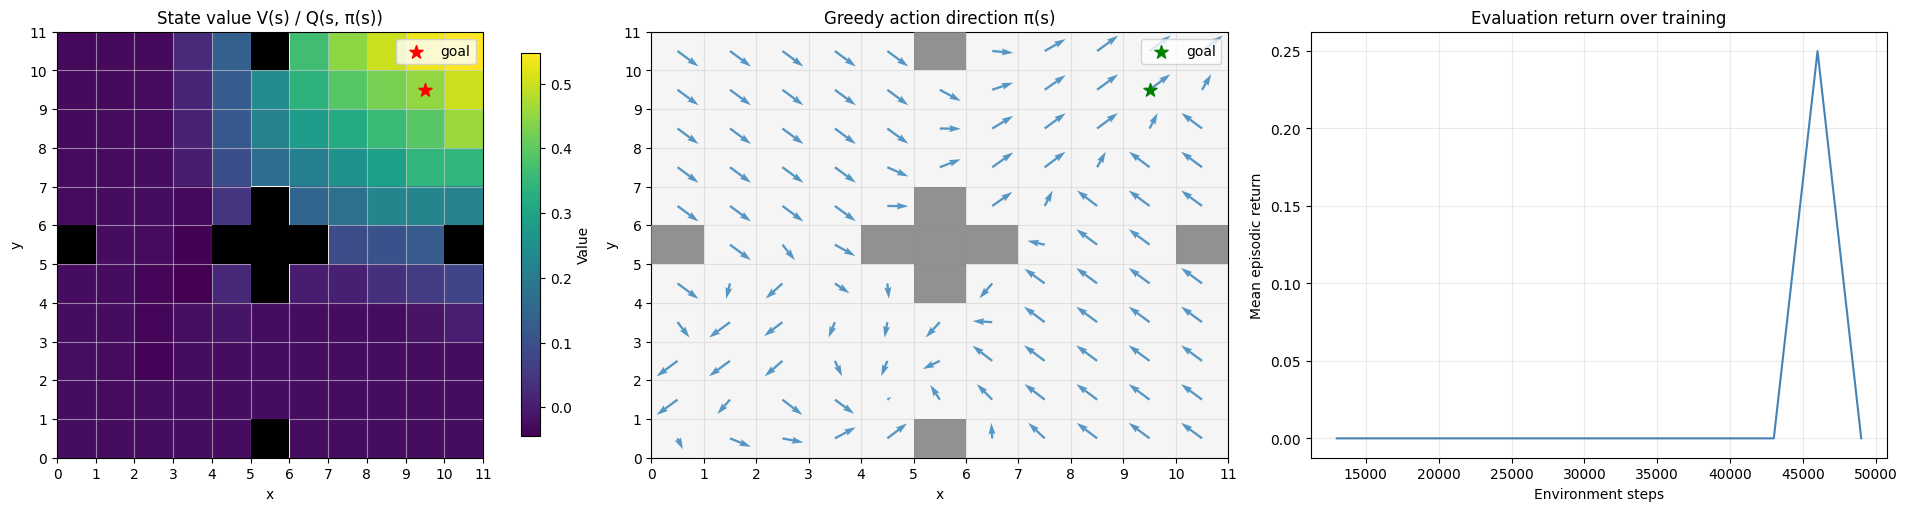

In [4]:

td3_actor.eval()
td3_q1.eval()

eval_env = make_env(goal=(9, 9))


def td3_policy_fn(obs):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        action = td3_actor(obs_t).squeeze(0).cpu().numpy().astype(np.float32)
    return action


def td3_value_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        a = td3_actor(obs_t)
        q = td3_q1(obs_t, a).squeeze(-1).cpu().numpy()
    return q


def td3_actor_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        actions = td3_actor(obs_t).cpu().numpy()
    return actions


plot_policy_rollouts(
    env=eval_env,
    policy_fn=td3_policy_fn,
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=False,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env.close()

eval_env = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env,
    value_fn=td3_value_fn,
    actor_fn=td3_actor_fn,
    is_discrete=False,
    goal_pos=(9, 9),
    eval_returns=td3_eval,
)

eval_env.close()